In [1]:
# Imports

import os
import sys
import numpy as np
import netCDF4 as nc
from tqdm.auto import tqdm # progress bar
import xarray as xr
import xesmf as xe
from cartopy.crs import PlateCarree
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
import glob
from matplotlib.colors import ListedColormap, BoundaryNorm
from dask.diagnostics import ProgressBar
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


In [2]:
ds1 = xr.open_dataset('/glade/work/netige/Data/VIKING/viking_obp_ssh_msc_residuals.nc')
viking_ds = xr.open_dataset("/glade/work/netige/Data/VIKING/obp_ssh_rm_dt.nc")

### Coarsen data to 3-deg and re-do stds

In [3]:
import numpy as np
import xarray as xr
from typing import Optional, Sequence, Union

import numpy as np
import xarray as xr
import dask

from typing import Union, Optional, Sequence, Dict

def bin_average_ll_true2d(
    da: xr.DataArray,
    *,
    res: float = 1.0,
    lat_name: str = "lat",
    lon_name: str = "lon",
    prechunk=None,
    postchunk=None,
) -> xr.DataArray:

    lat_vals = da[lat_name].values
    lon_vals = da[lon_name].values
    lat_min, lat_max = float(np.nanmin(lat_vals)), float(np.nanmax(lat_vals))
    lon_min, lon_max = float(np.nanmin(lon_vals)), float(np.nanmax(lon_vals))

    def make_bins(vmin, vmax, step):
        start = np.floor(vmin / step) * step
        stop  = np.ceil (vmax / step) * step
        edges = np.arange(start, stop + step, step, dtype=float)
        labels = (edges[:-1] + edges[1:]) / 2.0
        return edges, labels

    lat_bins, lat_labels = make_bins(lat_min, lat_max, res)
    lon_bins, lon_labels = make_bins(lon_min, lon_max, res)
    nlon = len(lon_labels)

    if prechunk is not None:
        da = da.chunk(prechunk)
    elif "time" in da.dims:
        da = da.chunk({"time": -1})

    # 1D bin indices on each axis
    ilat = xr.DataArray(
        np.digitize(da[lat_name].values, lat_bins) - 1,
        dims=(lat_name,),
        coords={lat_name: da[lat_name]},
    )
    ilon = xr.DataArray(
        np.digitize(da[lon_name].values, lon_bins) - 1,
        dims=(lon_name,),
        coords={lon_name: da[lon_name]},
    )

    # broadcast to 2D bin indices
    ilat2d, ilon2d = xr.broadcast(ilat, ilon)

    valid = (
        (ilat2d >= 0) & (ilat2d < len(lat_labels)) &
        (ilon2d >= 0) & (ilon2d < len(lon_labels))
    )

    gid2d = (ilat2d * nlon + ilon2d).where(valid)

    # stack spatial dims -> points, drop invalid gid points
    da2 = da.assign_coords(gid=gid2d)
    s = da2.stack(points=(lat_name, lon_name))
    s = s.where(np.isfinite(s["gid"]), drop=True)

    # group mean across ALL points in each (ilat, ilon) bin (true 2D)
    out = s.groupby("gid").mean("points", skipna=True)

    # attach ilat/ilon as coords *along gid* (this is allowed)
    gid_vals = out["gid"].values.astype(np.int64)
    out = out.assign_coords(
        ilat=("gid", (gid_vals // nlon).astype(np.int64)),
        ilon=("gid", (gid_vals %  nlon).astype(np.int64)),
    )

    # pivot gid -> (ilat, ilon) -> (lat, lon)
    out2 = (
        out.set_index(gid=["ilat", "ilon"])
           .unstack("gid")
           .rename({"ilat": "lat", "ilon": "lon"})
    )

    # now safely assign actual coordinate values for the bin centers
    out2 = out2.assign_coords(
        lat=("lat", lat_labels),
        lon=("lon", lon_labels),
    )

    if postchunk is not None:
        out2 = out2.chunk(postchunk)

    return out2


    # 5) Add simple metadata
    out.attrs.update({
        "bin_average": f"{res}° bins",
        "lat_range": (lat_min, lat_max),
        "lon_range": (lon_min, lon_max),
    })
    #out = out.chunk({"time": 12, "lat": -1, "lon": -1, "block_size": "6MiB"})
    return out

def remove_seasonal_cycle(ds, time_dim="time", groupby="time.month"):
    """
    Remove the seasonal mean cycle from an xarray dataset.

    Parameters:
    ds (xr.Dataset or xr.DataArray): Input dataset or data array.
    time_dim (str): Name of the time dimension.
    groupby (str): Grouping method, default is 'time.month' (monthly climatology).

    Returns:
    xr.Dataset or xr.DataArray: Dataset or data array with the seasonal cycle removed.
    """
    climatology = ds.groupby(groupby).mean(dim=time_dim)
    return climatology, ds.groupby(groupby) - climatology

In [4]:
with ProgressBar():
    obp_3deg = bin_average_ll_true2d(
            viking_ds["obp_rm_dt"]  ,
            res=3,
            lat_name="lat", lon_name="lon",
            # KEY CHANGE: small time chunks; single spatial chunks
            #prechunk={"time": -1, "lat": -1, "lon": -1},
            # Optional: reshape the OUTPUT into nicer worker-sized tiles
            #postchunk={"time": 12, "lat": 256, "lon": 256},
            #persist_cut=True,   # if your function supports this, it helps
        ).persist()

[########################################] | 100% Completed | 96.97 s


In [5]:
from dask.diagnostics import ProgressBar
import dask

# Rechunk to reduce task overhead
obp_3deg_rc = obp_3deg.chunk({"time": -1, "lat": 34, "lon": 40})  # single spatial chunk

# Or, if you prefer a couple chunks:
# obp_3deg_rc = obp_3deg.chunk({"time": -1, "lat": 17, "lon": 20})

msc, res = remove_seasonal_cycle(obp_3deg_rc)

# Persist (or compute) both together
with ProgressBar():
    viking_obp_MSC_3deg, viking_obp_res_3deg = dask.persist(msc, res)


[########################################] | 100% Completed | 341.59 ms


In [6]:
print(viking_obp_res_3deg, ds1["viking_obp_res"])


<xarray.DataArray 'obp_rm_dt' (time: 372, lat: 34, lon: 40)>
dask.array<sub, shape=(372, 34, 40), dtype=float32, chunksize=(1, 34, 40), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 -34.5 -31.5 -28.5 -25.5 -22.5 ... 55.5 58.5 61.5 64.5
  * lon      (lon) float64 -97.5 -94.5 -91.5 -88.5 -85.5 ... 10.5 13.5 16.5 19.5
  * time     (time) datetime64[ns] 1993-01-16T12:00:00 ... 2023-12-16T12:00:00
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12 <xarray.DataArray 'viking_obp_res' (time: 372, lat: 2267, lon: 2715)>
[2289624660 values with dtype=float32]
Coordinates:
  * lon      (lon) float64 -97.96 -97.91 -97.87 -97.83 ... 19.89 19.93 19.98
  * lat      (lat) float64 -33.48 -33.44 -33.39 -33.35 ... 64.9 64.94 64.99
  * time     (time) datetime64[ns] 1993-01-16T12:00:00 ... 2023-12-16T12:00:00


In [7]:
import numpy as np
import xarray as xr
import scipy.stats as stats
import dask
from dask.diagnostics import ProgressBar

# -------------------------
# Inputs (residual on time)
# -------------------------
obp_hr = ds1["viking_obp_res"]      # (time, lat_hr, lon_hr)  HUGE
obp_lr = viking_obp_res_3deg        # (time, lat_lr=34, lon_lr=40)

# Core dim "time" must be single chunk for dask='parallelized'
obp_lr = obp_lr.chunk({"time": -1, "lat": obp_lr.sizes["lat"], "lon": obp_lr.sizes["lon"]})
obp_hr = obp_hr.chunk({"time": -1, "lat": 200, "lon": 200})  # tune lat/lon chunks to your system

# -------------------------
# Build bin_id for each hi-res pixel based on low-res 3° bin centers
# -------------------------
lat_c = obp_lr["lat"].values
lon_c = obp_lr["lon"].values
nlon_lr = lon_c.size

dlat = float(np.median(np.diff(lat_c)))
dlon = float(np.median(np.diff(lon_c)))
lat_edges = np.concatenate([lat_c - dlat/2, [lat_c[-1] + dlat/2]])
lon_edges = np.concatenate([lon_c - dlon/2, [lon_c[-1] + dlon/2]])

ilat = np.digitize(obp_hr["lat"].values, lat_edges) - 1   # (lat_hr,)
ilon = np.digitize(obp_hr["lon"].values, lon_edges) - 1   # (lon_hr,)

ilat[(ilat < 0) | (ilat >= lat_c.size)] = -1
ilon[(ilon < 0) | (ilon >= lon_c.size)] = -1

ilat_da = xr.DataArray(ilat, dims=("lat",), coords={"lat": obp_hr["lat"]})
ilon_da = xr.DataArray(ilon, dims=("lon",), coords={"lon": obp_hr["lon"]})

ilat2d, ilon2d = xr.broadcast(ilat_da, ilon_da)
bin_id_2d = (ilat2d * nlon_lr + ilon2d).astype("int64")
bin_id_2d = bin_id_2d.where((ilat2d >= 0) & (ilon2d >= 0), other=-1)

obp_hr = obp_hr.assign_coords(bin_id=bin_id_2d)

# -------------------------
# Helpers: corr, counts, p-values
# -------------------------
def corr_1d_nan(x, y):
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 3:
        return np.nan
    x = x[m]; y = y[m]
    x = x - x.mean()
    y = y - y.mean()
    denom = np.sqrt((x*x).sum() * (y*y).sum())
    if denom == 0:
        return np.nan
    return (x*y).sum() / denom

def count_pairs_1d(x, y):
    m = np.isfinite(x) & np.isfinite(y)
    return m.sum()

def pval_from_r_n(r, n):
    if (not np.isfinite(r)) or (n < 3):
        return np.nan
    df = n - 2
    r = np.clip(r, -1 + 1e-12, 1 - 1e-12)
    t = r * np.sqrt(df / (1.0 - r*r))
    return 2.0 * stats.t.sf(np.abs(t), df)

alpha = 0.05

# -------------------------
# Stack hi-res space; group within each 3° bin; correlate bin series vs each point
# -------------------------
obp_stack = obp_hr.stack(points=("lat", "lon"))
obp_stack = obp_stack.where(obp_stack["bin_id"] >= 0, drop=True)
g = obp_stack.groupby("bin_id")

def corr_group_with_sig(y):
    """
    y: DataArray (time, points_in_bin) for one bin_id
    returns: Dataset with r, p, sig over points_in_bin
    """
    bid = int(y["bin_id"].values[0])
    ilat = bid // nlon_lr
    ilon = bid %  nlon_lr

    x = obp_lr.isel(lat=ilat, lon=ilon).chunk({"time": -1})
    y = y.chunk({"time": -1})

    r_bin = xr.apply_ufunc(
        corr_1d_nan,
        x, y,
        input_core_dims=[["time"], ["time"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[np.float32],
    )

    n_bin = xr.apply_ufunc(
        count_pairs_1d,
        x, y,
        input_core_dims=[["time"], ["time"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[np.int16],
    )

    p_bin = xr.apply_ufunc(
        pval_from_r_n,
        r_bin, n_bin,
        input_core_dims=[[], []],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[np.float64],
    )

    sig_bin = xr.where(p_bin < alpha, 1, 0).astype(np.int8).where(np.isfinite(p_bin))
    return xr.Dataset({"r": r_bin, "p": p_bin, "sig": sig_bin})

out_points = g.map(corr_group_with_sig)

# Unstack back to hi-res grids
r_hr   = out_points["r"].unstack("points").rename("corr_bin_vs_pixel_res")
p_hr   = out_points["p"].unstack("points").rename("pval_bin_vs_pixel_res")
sig_hr = out_points["sig"].unstack("points").rename("sigmask_bin_vs_pixel_res")

# -------------------------
# Compute (WARNING: global hi-res compute is extremely heavy)
# -------------------------
# Strongly recommend subsetting to a basin before compute:
# r_hr = r_hr.sel(lat=slice(...), lon=slice(...))
# same for p_hr, sig_hr

with ProgressBar():
    r_hr_c, p_hr_c, sig_hr_c = dask.compute(r_hr, p_hr, sig_hr)


[########################################] | 100% Completed | 18m 28s


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


# --- Colormap for difference panel (-0.03..0.03 by 0.005) ---
boundaries2 = np.arange(-1, 1.1, 0.1)   # include 0.03
base2 = plt.cm.get_cmap("coolwarm", len(boundaries2))
cmap2 = ListedColormap(base2(np.arange(base2.N)))
norm2 = BoundaryNorm(boundaries2, ncolors=cmap2.N)

def plot_corr_with_stippling(r, sig_mask, title="", extent=None, stride=5):
    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=(10, 6))
    ax = plt.axes(projection=proj)
    if extent is not None:
        ax.set_extent(extent, crs=proj)
        
    pm = ax.pcolormesh(
        r["lon"].values, r["lat"].values, r.values,
        transform=proj, 
        cmap=cmap2, norm=norm2, shading="auto"
    )

    levels = [200, 3000]
    cs = ax.contour(
        b_lon, b_lat, b_field,
        levels=levels, colors="yellow", linewidths=0.4,
        transform=ccrs.PlateCarree()
    )
    ax.clabel(cs, fmt="%d m", fontsize=4)
    cb = plt.colorbar(pm, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label("Correlation Coefficient")

    gl = ax.gridlines(color='gray', linestyle='--', linewidth=0.2, draw_labels=False)
    gl.bottom_labels = True
    gl.left_labels = True

    #ax.coastlines(resolution="110m", linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    #ax.add_feature(cfeature.BORDERS, linewidth=0.4)

    # Stippling: plot points where sig_mask == 1, decimated by stride for speed
    sig = (sig_mask == 0)
    sig_dec = sig.isel(lat=slice(None, None, stride), lon=slice(None, None, stride))

    lon2d, lat2d = np.meshgrid(sig_dec["lon"].values, sig_dec["lat"].values)
    ax.scatter(
        lon2d[sig_dec.values],
        lat2d[sig_dec.values],
        s=1,
        transform=proj,
        linewidths=0,
        color = '#636363',
        
    )

    ax.set_title(title or "Correlation with significance stippling (mask==1)")
    plt.tight_layout()
    plt.savefig("VIKING_OBP_Binned_Correlation_res_TM.png", dpi=500, bbox_inches='tight')
    plt.show()

# Example:


In [9]:
bathy = xr.open_dataset('/glade/work/netige/Data/Bathymetry/GLO-MFC_001_030_mask_bathy.nc')

In [10]:
data32 = bathy["deptho"].astype("float32")            # meters, positive down
data32 = data32.where(np.isfinite(data32)) 

data32 = data32.sel(
    latitude=slice(-33.5, 65),
    longitude=slice(-98, 20)
)
b_lat = data32["latitude"]; b_lon = data32["longitude"]; b_field = data32


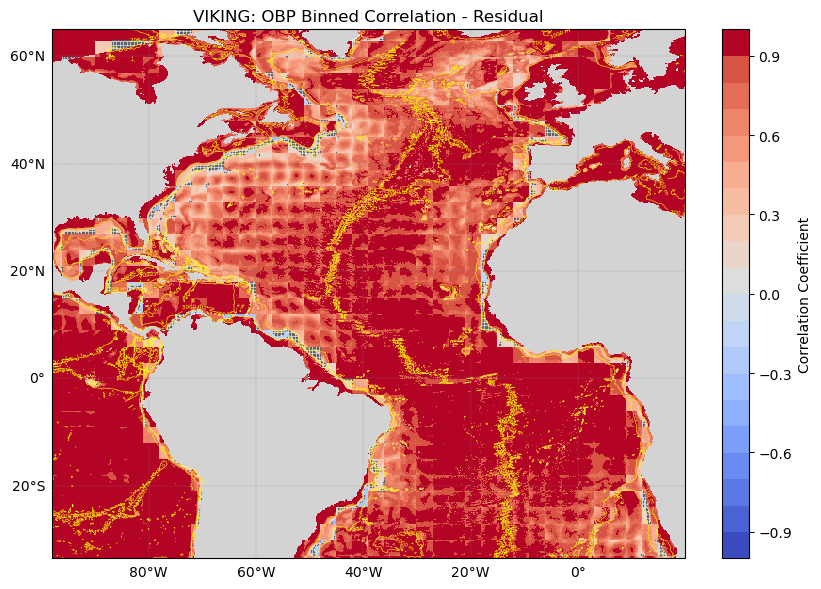

In [11]:
plot_corr_with_stippling(r_hr_c, sig_hr_c, title="VIKING: OBP Binned Correlation - Residual", stride=6)

### Compute normalized std dif between binned and HR OBP

In [12]:
import numpy as np
import xarray as xr
import dask
from dask.diagnostics import ProgressBar

def std_1d_nan(x):
    m = np.isfinite(x)
    if m.sum() < 2:
        return np.nan
    return np.std(x[m], ddof=1)

def std_resid_over_std_hr(x_lr, y_hr):
    """
    x_lr: 1D array (time,) LR bin series
    y_hr: 1D array (time,) HR pixel series
    returns: std(time)[y_hr - x_lr] / std(time)[y_hr]
    """
    m = np.isfinite(x_lr) & np.isfinite(y_hr)
    if m.sum() < 2:
        return np.nan
    r = y_hr[m] - x_lr[m]
    num = np.std(r, ddof=1)
    den = np.std(y_hr[m], ddof=1)
    if (not np.isfinite(den)) or den == 0:
        return np.nan
    return num / den


In [13]:
# -------------------------
# Inputs (residual on time)
# -------------------------
obp_hr = ds1["viking_obp_res"]      # (time, lat_hr, lon_hr)  HUGE
obp_lr = viking_obp_res_3deg        # (time, lat_lr=34, lon_lr=40)

# Core dim "time" must be single chunk for dask='parallelized'
obp_lr = obp_lr.chunk({"time": -1, "lat": obp_lr.sizes["lat"], "lon": obp_lr.sizes["lon"]})
obp_hr = obp_hr.chunk({"time": -1, "lat": 200, "lon": 200})  # tune lat/lon chunks to your system

# -------------------------
# Build bin_id for each hi-res pixel based on low-res 3° bin centers
# -------------------------
lat_c = obp_lr["lat"].values
lon_c = obp_lr["lon"].values
nlon_lr = lon_c.size

dlat = float(np.median(np.diff(lat_c)))
dlon = float(np.median(np.diff(lon_c)))
lat_edges = np.concatenate([lat_c - dlat/2, [lat_c[-1] + dlat/2]])
lon_edges = np.concatenate([lon_c - dlon/2, [lon_c[-1] + dlon/2]])

ilat = np.digitize(obp_hr["lat"].values, lat_edges) - 1   # (lat_hr,)
ilon = np.digitize(obp_hr["lon"].values, lon_edges) - 1   # (lon_hr,)

ilat[(ilat < 0) | (ilat >= lat_c.size)] = -1
ilon[(ilon < 0) | (ilon >= lon_c.size)] = -1

ilat_da = xr.DataArray(ilat, dims=("lat",), coords={"lat": obp_hr["lat"]})
ilon_da = xr.DataArray(ilon, dims=("lon",), coords={"lon": obp_hr["lon"]})

ilat2d, ilon2d = xr.broadcast(ilat_da, ilon_da)
bin_id_2d = (ilat2d * nlon_lr + ilon2d).astype("int64")
bin_id_2d = bin_id_2d.where((ilat2d >= 0) & (ilon2d >= 0), other=-1)

obp_hr = obp_hr.assign_coords(bin_id=bin_id_2d)


In [14]:
# -------------------------
# Inputs (same as before)
# -------------------------
#obp_hr = viking_ds["obp_rm_dt"]     # (time, lat_hr, lon_hr)
#obp_lr = obp_3deg                  # (time, lat_lr, lon_lr)

# Chunking: time must be single chunk for dask='parallelized' core dims
#obp_lr = obp_lr.chunk({"time": -1, "lat": obp_lr.sizes["lat"], "lon": obp_lr.sizes["lon"]})
#obp_hr = obp_hr.chunk({"time": -1, "lat": 200, "lon": 200})

# obp_hr must already have bin_id coord as you constructed earlier:
# obp_hr = obp_hr.assign_coords(bin_id=bin_id_2d)

# -------------------------
# Stack and group
# -------------------------
obp_stack = obp_hr.stack(points=("lat", "lon"))
obp_stack = obp_stack.where(obp_stack["bin_id"] >= 0, drop=True)
g = obp_stack.groupby("bin_id")

# Need these from earlier binning logic
lon_c = obp_lr["lon"].values
nlon_lr = lon_c.size

def nsd_group(y):
    """
    y: DataArray (time, points_in_bin) for one bin_id
    returns: Dataset with nsd, std_resid, std_hr over points_in_bin
    """
    # Grab the original points index (MultiIndex) BEFORE we drop coords
    pts_index = y.indexes["points"]          # <-- this is the key
    pts_coord = xr.IndexVariable("points", pts_index)

    bid = int(y["bin_id"].values[0])
    ilat = bid // nlon_lr
    ilon = bid %  nlon_lr

    # LR series (time,) drop scalar coords to avoid conflicts
    x = obp_lr.isel(lat=ilat, lon=ilon).reset_coords(drop=True).chunk({"time": -1})

    # HR group (time, points) drop coords (keep dimension)
    y0 = y.reset_coords(drop=True).chunk({"time": -1})

    # ---- compute metrics
    nsd = xr.apply_ufunc(
        std_resid_over_std_hr,
        x, y0,
        input_core_dims=[["time"], ["time"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[np.float32],
    )

    std_resid = xr.apply_ufunc(
        lambda x_lr, y_hr: std_1d_nan(y_hr - x_lr),
        x, y0,
        input_core_dims=[["time"], ["time"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[np.float32],
    )

    std_hr = xr.apply_ufunc(
        std_1d_nan,
        y0,
        input_core_dims=[["time"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[np.float32],
    )

    # ---- FORCE all outputs to share the exact same points index object
    nsd = nsd.assign_coords(points=pts_coord)
    std_resid = std_resid.assign_coords(points=pts_coord)
    std_hr = std_hr.assign_coords(points=pts_coord)

    return xr.Dataset({"nsd": nsd, "std_resid": std_resid, "std_hr": std_hr})

out_points = g.map(nsd_group)

nsd_hr       = out_points["nsd"].unstack("points").rename("std_resid_over_std_hr")
std_resid_hr = out_points["std_resid"].unstack("points").rename("std_resid")
std_hr_hr    = out_points["std_hr"].unstack("points").rename("std_hr")

# -------------------------
# Compute (still heavy globally)
# -------------------------
# Strongly recommended: subset before compute
# nsd_hr = nsd_hr.sel(lat=slice(...), lon=slice(...))

#with ProgressBar():
#    nsd_hr_c, std_resid_hr_c, std_hr_hr_c = dask.compute(nsd_hr, std_resid_hr, std_hr_hr)


In [15]:
with ProgressBar():
    nsd_hr_c, std_resid_hr_c, std_hr_hr_c = dask.compute(nsd_hr, std_resid_hr, std_hr_hr)


[########################################] | 100% Completed | 17m 3ss


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_nsd_map_discrete_greenbin(
    nsd,
    title="",
    extent=None,
    savepath="VIKING_OBP_NSD_discrete.png",
    bathy_contours=(200, 3000),
):
    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=(10, 6))
    ax = plt.axes(projection=proj)

    if extent is not None:
        ax.set_extent(extent, crs=proj)

    # --- Bin edges:
    # 0..1 by 0.1 gives 10 bins, then add one extra tiny bin for (>1) to show green on the colorbar.
    boundaries = np.r_[np.arange(0.0, 1.0, 0.1), 1.0, 1.0 + 0.1]  # length 12 -> 11 bins

    # --- Colors:
    # 10 plasma bins for [0,1], plus 1 green bin for (>1)
    plasma = plt.cm.get_cmap("Reds_r")
    plasma_colors = plasma(np.linspace(0.0, 1.0, 10))     # 10 discrete colors
    green = np.array([[66/255, 146/255, 198/255, 1.0]])              # RGBA
    cmap = ListedColormap(np.vstack([plasma_colors, green]))  # 11 colors total

    norm = BoundaryNorm(boundaries, ncolors=cmap.N, clip=False)

    pm = ax.pcolormesh(
        nsd["lon"].values, nsd["lat"].values, nsd.values,
        transform=proj,
        cmap=cmap,
        norm=norm,
        shading="auto"
    )

    # --- bathymetry contours (assumes b_lon, b_lat, b_field exist)
    if bathy_contours is not None:
        cs = ax.contour(
            b_lon, b_lat, b_field,
            levels=list(bathy_contours),
            colors="yellow",
            linewidths=0.4,
            transform=proj
        )
        ax.clabel(cs, fmt="%d m", fontsize=4)

    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)

    gl = ax.gridlines(color="gray", linestyle="--", linewidth=0.2, draw_labels=False)
    gl.bottom_labels = True
    gl.left_labels = True

    # --- Colorbar ticks must be exactly 0..1 by 0.1
    ticks = np.arange(0.0, 1.0 + 0.1, 0.1)

    cb = plt.colorbar(
        pm,
        ax=ax,
        fraction=0.046,
        pad=0.04,
        ticks=ticks,
        boundaries=boundaries,
        spacing="proportional"
    )
    #cb.set_label("NSD = std(HR − LR) / std(HR)")
    cb.set_ticklabels([f"{t:.1f}" for t in ticks])

    ax.set_title(title or "NSD (discrete plasma 0–1; green > 1)")
    plt.tight_layout()
    plt.savefig(savepath, dpi=500, bbox_inches="tight")
    plt.show()


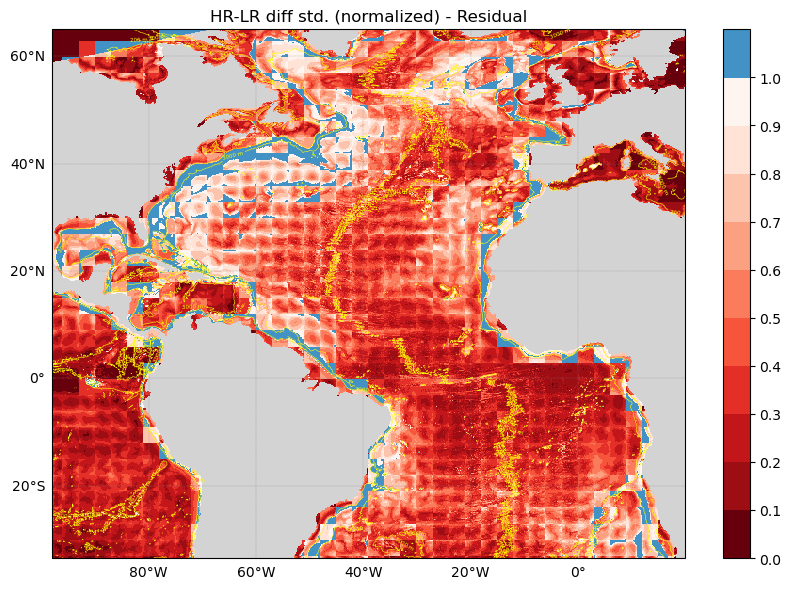

In [17]:
plot_nsd_map_discrete_greenbin(
    nsd_hr_c,
    title="HR-LR diff std. (normalized) - Residual",
    savepath="VIKING_OBP_NSD_res_TM.png"
)
